<a href="https://colab.research.google.com/github/Linda-Masia/MIT-805---Vincent-Mabuza-Linda-Masia/blob/main/Build_Processing_Set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cloning the Repo and Assessing Its Content

In [12]:
!git clone https://github.com/Linda-Masia/MIT-805---Vincent-Mabuza-Linda-Masia.git
%cd MIT-805---Vincent-Mabuza-Linda-Masia

Cloning into 'MIT-805---Vincent-Mabuza-Linda-Masia'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 81 (delta 23), reused 50 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (81/81), 2.95 MiB | 12.48 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/MIT-805---Vincent-Mabuza-Linda-Masia/MIT-805---Vincent-Mabuza-Linda-Masia


In [8]:
!pip install nbconvert --quiet
!jupyter nbconvert --to script EDA.ipynb --output EDA_extracted
print(open("EDA_extracted.py", encoding="utf-8").read())

#!/usr/bin/env python
# coding: utf-8

# ## 1. Import Required Libraries

# In[1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import pyarrow.parquet as pq

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded successfully")


# ## 2. Dataset Paths and Sampling Settings

# In[2]:


DATASETS = {
    "FHV": Path("../data/raw/fhv"),
    "FHVHV": Path("../data/raw/fhvhv"),
    "Green": Path("../data/raw/green"),
    "Yellow": Path("../data/raw/yellow"),
}

SAMPLE_ROWS_PER_DATASET = 250_000
RANDOM_STATE = 42

for name, path in DATASETS.items():
    files = sorted(path.glob("*.parquet"))
    print(f"{name:8} | {len(files):4} files | {path}")


# ## 3. Representative Sampling

# In[3]:


SAMPLE_CONFIG = {
    "FHV": 13_800_000,
    "FHVHV": 4_400_000,
    "Green": 6_000_000,
    "Yellow": 6_350_000,
}

RANDOM_STATE = 42

de

[NbConvertApp] Converting notebook EDA.ipynb to script
[NbConvertApp] Writing 12602 bytes to EDA_extracted.py


In [1]:
!cat ../src/download_data.py

'cat' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
!pip install -r ../requirements.txt --quiet

### N.B - Next cell downloads the Dataset via download_data.py 

In [4]:
!python ../src/download_data.py

Removing incomplete file: data\raw\fhvhv\fhvhv_tripdata_2025-06.parquet.part


Traceback (most recent call last):
  File "c:\Users\Ketlane_PS\OneDrive\Desktop\MIT-805---Vincent-Mabuza-Linda-Masia\src\download_data.py", line 132, in <module>
    file.unlink()
    ~~~~~~~~~~~^^
  File "c:\python314\Lib\pathlib\__init__.py", line 1047, in unlink
    os.unlink(self)
    ~~~~~~~~~^^^^^^
PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'data\\raw\\fhvhv\\fhvhv_tripdata_2025-06.parquet.part'


In [5]:
!ls ../src/

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [31]:
!ls -R ../src/ notebooks/

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [6]:
!pip install nbconvert --quiet
!jupyter nbconvert --to script notebooks/EDA.ipynb --output EDA_extracted
!cat ../notebooks/EDA_extracted.py

This application is used to convert notebook files (*.ipynb) to various other
formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    Execute the notebook prior to export.
    Equivalent to: [--ExecutePreprocess

[NbConvertApp] WARNING | pattern 'notebooks/EDA.ipynb' matched no files
'cat' is not recognized as an internal or external command,
operable program or batch file.


# Building the Processing Set

In [7]:
"""
build_processing_set.py

The processing dataset (3.52 GB) was constructed by randomly sampling row groups (seed=42) from each of the four raw TLC datasets (Yellow, Green, FHV, FHV-HV), using the same representative sampling methodology applied during Part 1 exploratory analysis, to ensure methodological consistency between the two parts of the project
"""

from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import pyarrow as pa
import gc
import os

RAW_DIR = Path("../data/raw")
PROCESSING_DIR = Path("../data/processing")
PROCESSING_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    "yellow": RAW_DIR / "yellow",
    "green": RAW_DIR / "green",
    "fhv": RAW_DIR / "fhv",
    "fhvhv": RAW_DIR / "fhvhv",
}

RANDOM_STATE = 42

TARGET_GB_PER_DATASET = 1.5


def downcast_dtypes(df):
    """Reduce memory footprint by downcasting float columns only to avoid int overflow issues."""
    for col in df.select_dtypes(include=["float64"]).columns:
        df[col] = pd.to_numeric(df[col], downcast="float")
    # Skip aggressive integer downcasting to prevent schema casting failures with values exceeding int8/int16 ranges
    return df


def get_dir_size_gb(path):
    total = 0
    for dirpath, _, filenames in os.walk(path):
        for f in filenames:
            total += os.path.getsize(os.path.join(dirpath, f))
    return total / (1024 ** 3)


def sample_dataset_to_target_size(name, folder, target_gb, random_state=42):
    """
    Randomly samples row groups from a dataset's raw parquet files (same
    approach as the Part 1 EDA notebook), writing out incrementally and
    stopping once the target size on disk is reached. Never holds more
    than a few row groups in memory at once. Aligns schemas to prevent
    crashes from evolving/missing columns.
    """
    rng = np.random.default_rng(random_state)
    files = sorted(Path(folder).glob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet files found in {folder}")

    # Build a list of (file, row_group_index) pairs and shuffle

    row_groups = []
    for file in files:
        pf = pq.ParquetFile(file)
        for rg in range(pf.num_row_groups):
            row_groups.append((file, rg))

    order = rng.permutation(len(row_groups))

    out_path = PROCESSING_DIR / f"{name}_processing.parquet"
    target_bytes = target_gb * (1024 ** 3)

    writer = None
    total_rows = 0
    writer_schema = None

    for idx in order:
        file, rg = row_groups[idx]
        pf = pq.ParquetFile(file)
        table = pf.read_row_group(rg)

        df_chunk = table.to_pandas()
        df_chunk = downcast_dtypes(df_chunk)

        # Aligns chunk schema with the expected schema for the ParquetWriter
        if writer_schema is not None:
            # Add missing columns
            for field in writer_schema:
                if field.name not in df_chunk.columns:
                    df_chunk[field.name] = np.nan
            # Reorder and cast types to match writer_schema
            col_order = [field.name for field in writer_schema]
            df_chunk = df_chunk[col_order]

        chunk_table = pa.Table.from_pandas(df_chunk, preserve_index=False)

        if writer is None:
            # Define the initial schema
            schema_fields = []
            for field in chunk_table.schema:
                # Avoid NullType which causes issues when other chunks have string data
                if pa.types.is_null(field.type):
                    schema_fields.append(pa.field(field.name, pa.string(), nullable=True))
                else:
                    schema_fields.append(field)
            writer_schema = pa.schema(schema_fields)
            chunk_table = chunk_table.cast(writer_schema)
            writer = pq.ParquetWriter(out_path, writer_schema)
        else:
            # Ensure exact schema match before appending
            chunk_table = chunk_table.cast(writer_schema)

        writer.write_table(chunk_table)
        total_rows += len(df_chunk)

        del df_chunk, table, chunk_table
        gc.collect()

        current_size = out_path.stat().st_size / (1024 ** 3)
        if current_size >= target_gb:
            break

    if writer is not None:
        writer.close()

    final_size_gb = out_path.stat().st_size / (1024 ** 3) if out_path.exists() else 0
    print(f"  {name}: {total_rows:,} rows written, {final_size_gb:.2f} GB -> {out_path}")
    return final_size_gb


if __name__ == "__main__":
    print("Building Part 2 processing dataset from raw TLC data...")
    print(f"Target per dataset: {TARGET_GB_PER_DATASET} GB "
          f"(combined target: {TARGET_GB_PER_DATASET * len(DATASETS)} GB)\n")

    results = {}
    for name, folder in DATASETS.items():
        print(f"Sampling {name}...")
        size_gb = sample_dataset_to_target_size(
            name, folder, target_gb=TARGET_GB_PER_DATASET, random_state=RANDOM_STATE
        )
        results[name] = size_gb

    total_size = get_dir_size_gb(PROCESSING_DIR)
    print("\n" + "=" * 50)
    print("PROCESSING SET SUMMARY")
    print("=" * 50)
    for name, size in results.items():
        print(f"  {name}: {size:.2f} GB")
    print(f"\nTotal processing set size: {total_size:.2f} GB")

    if total_size < 3.0:
        print("WARNING: total is below the 3GB minimum - increase "
              "TARGET_GB_PER_DATASET and re-run.")
    else:
        print("Target met (>= 3GB).")

    print("\nSuggested report sentence:")
    print(f'"The processing dataset ({total_size:.2f} GB) was constructed by '
          f'randomly sampling row groups (seed=42) from each of the four raw '
          f'TLC datasets (Yellow, Green, FHV, FHV-HV), using the same '
          f'representative sampling methodology applied during Part 1 '
          f'exploratory analysis, to ensure methodological consistency '
          f'between the two parts of the project."')


Building Part 2 processing dataset from raw TLC data...
Target per dataset: 1.5 GB (combined target: 6.0 GB)

Sampling yellow...
  yellow: 78,463,852 rows written, 1.50 GB -> ..\data\processing\yellow_processing.parquet
Sampling green...
  green: 1,067,809 rows written, 0.03 GB -> ..\data\processing\green_processing.parquet
Sampling fhv...
  fhv: 39,239,405 rows written, 0.48 GB -> ..\data\processing\fhv_processing.parquet
Sampling fhvhv...
  fhvhv: 62,122,411 rows written, 1.51 GB -> ..\data\processing\fhvhv_processing.parquet

PROCESSING SET SUMMARY
  yellow: 1.50 GB
  green: 0.03 GB
  fhv: 0.48 GB
  fhvhv: 1.51 GB

Total processing set size: 3.52 GB
Target met (>= 3GB).

Suggested report sentence:
"The processing dataset (3.52 GB) was constructed by randomly sampling row groups (seed=42) from each of the four raw TLC datasets (Yellow, Green, FHV, FHV-HV), using the same representative sampling methodology applied during Part 1 exploratory analysis, to ensure methodological consisten

# PySpark MapReduce Analysis

### 1. Processing objective & analytical question

**Central question:** *How do the four NYC TLC services (Yellow, Green, FHV, FHVHV) differ in **when** and **where** they pick up passengers, and which borough/zone/hour combinations concentrate the most demand?*

**Why it matters:** dispatchers and drivers need to know where to position vehicles by hour, and the TLC / city planners need to know how app-based (FHVHV) demand compares with street-hail (Yellow/Green) demand across boroughs and between weekdays and weekends.

**Approach (MapReduce style in PySpark):**
1. **Map** - standardise four different schemas into one (service, pickup time, zone, fare), drop invalid records and derive keys (hour, weekday/weekend).
2. **Shuffle** - group by key `(service, weekend?, hour, pickup zone)`.
3. **Reduce** - aggregate trip counts and fares per key.
4. Join the small result with the TLC zone lookup (broadcast join) so results are readable (zone and borough names).

> **Note:** the processing set is a row-group sample taken per service until ~1.5 GB each, so sampling fractions differ per service. Raw trip counts are therefore **not comparable between services**. All cross-service comparisons below use *share of the service's own trips*.

In [8]:
# JAVA CHECK: make sure Spark launches with the correct Java (17)
# It MUST run before the SparkSession is created (the JVM is launched once per kernel).

import glob
import os
import re
import shutil
import subprocess
import sys

REQUIRED_JAVA_MAJOR = 17  


def java_major(java_home):
    """Major Java version of a JAVA_HOME folder, or None if it is not a working JDK/JRE."""
    exe = os.path.join(java_home, "bin", "java.exe" if os.name == "nt" else "java")
    if not os.path.isfile(exe):
        return None
    try:
        out = subprocess.run([exe, "-version"], capture_output=True, text=True, timeout=30).stderr
    except Exception:
        return None
    m = re.search(r'version "(\d+)(?:\.(\d+))?', out)
    if not m:
        return None
    major = int(m.group(1))
    return int(m.group(2)) if major == 1 else major


def candidate_java_homes():
    """Yield possible JAVA_HOME folders: current env first, then common install locations."""
    if os.environ.get("JAVA_HOME"):
        yield os.environ["JAVA_HOME"]

    patterns = []
    if os.name == "nt":                                   # Windows
        bases = {os.environ.get("ProgramFiles", r"C:\Program Files"),
                 os.environ.get("ProgramFiles(x86)", r"C:\Program Files (x86)")}
        vendors = ["Microsoft", "Eclipse Adoptium", "Java", "Amazon Corretto", "Zulu", "BellSoft", "Semeru"]
        for base in bases:
            for vendor in vendors:
                patterns += [os.path.join(base, vendor, "jdk*17*"), os.path.join(base, vendor, "jre*17*")]
    elif sys.platform == "darwin":                        # macOS
        patterns += ["/Library/Java/JavaVirtualMachines/*17*/Contents/Home",
                     "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home",
                     "/usr/local/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"]
    else:                                                 # Linux / Google Colab
        patterns += ["/usr/lib/jvm/*17*"]

    for pattern in patterns:
        for home in sorted(glob.glob(pattern), reverse=True):
            yield home

    java_on_path = shutil.which("java")                   # whatever `java` resolves to on PATH
    if java_on_path:
        yield os.path.dirname(os.path.dirname(os.path.realpath(java_on_path)))


def find_java():
    for home in dict.fromkeys(candidate_java_homes()):    # de-duplicated, order preserved
        if java_major(home) == REQUIRED_JAVA_MAJOR:
            return home
    return None


java_home = find_java()

if java_home is None and sys.platform.startswith("linux") and shutil.which("apt-get"):
    print(f"Java {REQUIRED_JAVA_MAJOR} not found - installing with apt-get ...")
    subprocess.run(["apt-get", "update", "-qq"], check=False)
    subprocess.run(["apt-get", "install", "-y", "-qq", f"openjdk-{REQUIRED_JAVA_MAJOR}-jre-headless"],
                   check=False)
    java_home = find_java()

if java_home is None:
    raise RuntimeError(
        f"Java {REQUIRED_JAVA_MAJOR} was not found.\n"
        f"  Windows : winget install Microsoft.OpenJDK.{REQUIRED_JAVA_MAJOR}\n"
        f"  macOS   : brew install openjdk@{REQUIRED_JAVA_MAJOR}\n"
        f"  Linux   : sudo apt-get install openjdk-{REQUIRED_JAVA_MAJOR}-jre-headless\n"
        "Then restart the kernel and run this cell again."
    )

os.environ["JAVA_HOME"] = java_home
os.environ["PATH"] = os.path.join(java_home, "bin") + os.pathsep + os.environ["PATH"]

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

print("JAVA_HOME:", java_home)
print(subprocess.run(["java", "-version"], capture_output=True, text=True).stderr)

JAVA_HOME: C:\Program Files\Microsoft\jdk-17.0.20.101-hotspot\
openjdk version "17.0.20.1" 2026-08-18 LTS
OpenJDK Runtime Environment Microsoft-14940689 (build 17.0.20.1+1-LTS)
OpenJDK 64-Bit Server VM Microsoft-14940689 (build 17.0.20.1+1-LTS, mixed mode, sharing)



In [9]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("TLC_MapReduce_Analysis")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    # TLC timestamps are NYC wall-clock times: UTC session time zone stops Spark shifting the hour
    .config("spark.sql.session.timeZone", "UTC")
    # default is 200 shuffle partitions, which is far too many for a single laptop
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)
sc = spark.sparkContext

# Guarantee the JVM that is *actually running* is the right one (catches a stale session
# created earlier in this kernel with a different Java -> restart the kernel if this fails).
jvm_version = spark._jvm.System.getProperty("java.version")
assert jvm_version.split(".")[0] == str(REQUIRED_JAVA_MAJOR), (
    f"Spark is running on Java {jvm_version}, expected {REQUIRED_JAVA_MAJOR}. "
    "Restart the kernel and run the Java cell first."
)

print(f"Spark {spark.version} | Java {jvm_version} | master={sc.master} | cores={sc.defaultParallelism}")
print("Spark UI (keep this session open to screenshot DAG/stages):", sc.uiWebUrl)

C:\Users\Ketlane_PS\AppData\Roaming\Python\Python314\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Spark 4.2.0 | Java 17.0.20.1 | master=local[*] | cores=12
Spark UI (keep this session open to screenshot DAG/stages): http://LAPTOP-BM7TGIQ4:4041


### MapReduce implementation

In [10]:
import re
from pathlib import Path

import pandas as pd
from pyspark.sql import functions as F

yellow_path = "../data/processing/yellow_processing.parquet"
green_path = "../data/processing/green_processing.parquet"
fhv_path = "../data/processing/fhv_processing.parquet"
fhvhv_path = "../data/processing/fhvhv_processing.parquet"

df_yellow = spark.read.parquet(yellow_path)
df_green = spark.read.parquet(green_path)
df_fhv = spark.read.parquet(fhv_path)
df_fhvhv = spark.read.parquet(fhvhv_path)

months = sorted({m.group(0) for f in Path("data/raw").glob("*/*.parquet")
                 if (m := re.search(r"\d{4}-\d{2}", f.name))})
if months:
    DATE_MIN = pd.Period(months[0]).start_time.strftime("%Y-%m-%d")
    DATE_MAX = (pd.Period(months[-1]) + 1).start_time.strftime("%Y-%m-%d")     
else:                                                                         
    DATE_MIN, DATE_MAX = "2024-01-01", "2026-02-01"
print(f"Expected pickup range: {DATE_MIN} <= pickup < {DATE_MAX}")


def standardise(df, service, ts_col, fare_col=None):
    """Project one service onto (service_type, pickup_ts, PULocationID, fare)."""
    fare = F.col(fare_col).cast("double") if fare_col else F.lit(None).cast("double")
    return df.select(
        F.lit(service).alias("service_type"),
        F.col(ts_col).alias("pickup_ts"),
        F.col("PULocationID").cast("integer").alias("PULocationID"),
        fare.alias("fare"),
    )


raw_mapped = (
    standardise(df_yellow, "Yellow", "tpep_pickup_datetime", "fare_amount")
    .union(standardise(df_green, "Green", "lpep_pickup_datetime", "fare_amount"))
    .union(standardise(df_fhv, "FHV", "pickup_datetime"))
    .union(standardise(df_fhvhv, "FHVHV", "pickup_datetime", "base_passenger_fare"))        # pickup time, NOT request time
)

START_TS, END_TS = F.to_timestamp(F.lit(DATE_MIN)), F.to_timestamp(F.lit(DATE_MAX))

quality = (
    raw_mapped.groupBy("service_type").agg(
        F.count("*").alias("rows"),
        F.sum(F.col("pickup_ts").isNull().cast("int")).alias("null_pickup_time"),
        F.sum(F.col("PULocationID").isNull().cast("int")).alias("null_pickup_zone"),
        F.sum(((F.col("pickup_ts") < START_TS) | (F.col("pickup_ts") >= END_TS)).cast("int")).alias("outside_date_range"),
        F.sum(((F.col("PULocationID") < 1) | (F.col("PULocationID") > 265)).cast("int")).alias("invalid_zone_id"),
        F.sum((F.col("fare") <= 0).cast("int")).alias("non_positive_fare"),
    )
    .toPandas().set_index("service_type")
)
quality["pct_null_zone"] = (100 * quality["null_pickup_zone"] / quality["rows"]).round(2)
display(quality)

mapped = (
    raw_mapped
    .filter(F.col("pickup_ts").isNotNull()
            & F.col("PULocationID").between(1, 265)
            & (F.col("pickup_ts") >= START_TS) & (F.col("pickup_ts") < END_TS))
    .withColumn("pickup_hour", F.hour("pickup_ts"))
    .withColumn("is_weekend", F.dayofweek("pickup_ts").isin(1, 7))
    .withColumn("fare", F.when((F.col("fare") > 0) & (F.col("fare") < 500), F.col("fare")))
    .drop("pickup_ts")
)
mapped.printSchema()

Expected pickup range: 2025-06-01 <= pickup < 2026-02-01


C:\Users\Ketlane_PS\AppData\Roaming\Python\Python314\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,rows,null_pickup_time,null_pickup_zone,outside_date_range,invalid_zone_id,non_positive_fare,pct_null_zone
service_type,,,,,,,
Yellow,78463852,0,0,46812524,0,3093561.0,0.00
Green,1067809,0,0,690209,0,6871.0,0.00
FHV,39239405,0,31998424,21820160,0,NaN,81.55
FHVHV,62122411,0,0,39695322,0,132759.0,0.00


root
 |-- service_type: string (nullable = false)
 |-- PULocationID: integer (nullable = true)
 |-- fare: double (nullable = true)
 |-- pickup_hour: integer (nullable = true)
 |-- is_weekend: boolean (nullable = true)



In [11]:
import requests

ZONE_FILE = Path("../data/taxi_zone_lookup.csv")
ZONE_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

if not ZONE_FILE.exists():
    ZONE_FILE.parent.mkdir(parents=True, exist_ok=True)
    ZONE_FILE.write_bytes(requests.get(ZONE_URL, timeout=60).content)

zones = (
    spark.read.csv(str(ZONE_FILE), header=True, inferSchema=True)
    .select(F.col("LocationID").cast("integer").alias("PULocationID"), "Borough", "Zone")
)
print("zones:", zones.count(), "rows")

zones: 265 rows


In [12]:
demand = (
    mapped.groupBy("service_type", "is_weekend", "pickup_hour", "PULocationID")
    .agg(
        F.count("*").alias("trip_count"),
        F.sum("fare").alias("fare_sum"),
        F.count("fare").alias("fare_n"),
    )
)

demand_peaks = demand.orderBy(F.desc("trip_count"))

demand_peaks.explain("formatted")

== Physical Plan ==
AdaptiveSparkPlan (22)
+- Sort (21)
   +- Exchange (20)
      +- HashAggregate (19)
         +- Exchange (18)
            +- HashAggregate (17)
               +- Union (16)
                  :- Project (4)
                  :  +- Project (3)
                  :     +- Filter (2)
                  :        +- Scan parquet  (1)
                  :- Project (8)
                  :  +- Project (7)
                  :     +- Filter (6)
                  :        +- Scan parquet  (5)
                  :- Project (11)
                  :  +- Filter (10)
                  :     +- Scan parquet  (9)
                  +- Project (15)
                     +- Project (14)
                        +- Filter (13)
                           +- Scan parquet  (12)


(1) Scan parquet 
Output [3]: [tpep_pickup_datetime#1, PULocationID#7, fare_amount#10]
Batched: true
Location: InMemoryFileIndex [file:/c:/Users/Ketlane_PS/OneDrive/Desktop/MIT-805---Vincent-Mabuza-Linda-Masia/data/proces

### Distributed execution evidence

Reading the physical plan above from the bottom up: `Scan parquet` -> `Filter/Project` (the **map**, narrow transformations pipelined in one stage) -> `HashAggregate (partial)` (map-side combine) -> **`Exchange hashpartitioning`** (the **shuffle** by key, a stage boundary) -> `HashAggregate (final)` (the **reduce**) -> **`Exchange rangepartitioning`** (second shuffle for the global sort) -> `Sort`.

Unlike Hadoop MapReduce (Map -> write to disk -> Shuffle -> Reduce -> write to HDFS, repeated for every job), Spark compiles the whole query into one DAG, pipelines narrow steps in memory inside a stage, and only breaks into a new stage at a shuffle.

In [13]:
import json
import time
import urllib.request

def timed_run(partitions, label):
    spark.conf.set("spark.sql.shuffle.partitions", str(partitions))
    spark.conf.set("spark.sql.adaptive.enabled", "false")
    sc.setJobDescription(label)
    start = time.time()
    demand.write.format("noop").mode("overwrite").save()     # runs the full query, discards the output
    return time.time() - start

timings = {p: timed_run(p, f"groupBy with {p} shuffle partitions") for p in (200, 16)}
for p, secs in timings.items():
    print(f"shuffle.partitions={p:>3}: {secs:6.1f} s")

spark.conf.set("spark.sql.shuffle.partitions", "16")
spark.conf.set("spark.sql.adaptive.enabled", "true")

sc.setJobDescription("join demand with zones")
print("\n=== Broadcast join (small zones table is copied to every executor, big side is NOT shuffled) ===")
demand.join(F.broadcast(zones), "PULocationID", "left").explain()
print("\n=== Sort-merge join (both sides are shuffled by PULocationID and sorted) ===")
demand.join(zones.hint("merge"), "PULocationID", "left").explain()

sc.setJobDescription("materialise demand aggregate")
demand.cache()
print("\nAggregated keys:", f"{demand.count():,}", "rows (cached)")

def stage_summary():
    app_id = sc.applicationId
    url = f"{sc.uiWebUrl}/api/v1/applications/{app_id}/stages"
    stages = json.load(urllib.request.urlopen(url))
    rows = [{
        "stage": s["stageId"],
        "job description": (s.get("description") or s["name"])[:45],
        "tasks": s["numTasks"],
        "shuffle_write_MB": round(s["shuffleWriteBytes"] / 1e6, 2),
        "shuffle_read_MB": round(s["shuffleReadBytes"] / 1e6, 2),
        "input_MB": round(s["inputBytes"] / 1e6, 1),
        "seconds": round(((pd.Timestamp(s["completionTime"][:-3]) - pd.Timestamp(s["submissionTime"][:-3])).total_seconds())
                         if s.get("completionTime") and s.get("submissionTime") else float("nan"), 1),
    } for s in stages if s["status"] == "COMPLETE"]
    return pd.DataFrame(rows).sort_values("stage")


try:
    display(stage_summary())
except Exception as e:
    print("Could not read Spark UI REST API:", e)
print("Spark UI:", sc.uiWebUrl, " -> screenshot the Jobs, Stages and SQL tabs (DAG visualisation) for the report")

shuffle.partitions=200:   11.2 s
shuffle.partitions= 16:    6.5 s

=== Broadcast join (small zones table is copied to every executor, big side is NOT shuffled) ===
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [PULocationID#75, service_type#73, is_weekend#132, pickup_hour#131, trip_count#164L, fare_sum#165, fare_n#166L, Borough#152, Zone#153]
   +- BroadcastHashJoin [PULocationID#75], [PULocationID#155], LeftOuter, BuildRight, false, false
      :- HashAggregate(keys=[service_type#73, is_weekend#132, pickup_hour#131, PULocationID#75], functions=[count(1), sum(fare#133), count(fare#133)])
      :  +- Exchange hashpartitioning(service_type#73, is_weekend#132, pickup_hour#131, PULocationID#75, 16), ENSURE_REQUIREMENTS, [plan_id=623]
      :     +- HashAggregate(keys=[service_type#73, is_weekend#132, pickup_hour#131, PULocationID#75], functions=[partial_count(1), partial_sum(fare#133), partial_count(fare#133)])
      :        +- Union
      :           :- Project [Yell

,stage,job description,tasks,shuffle_write_MB,shuffle_read_MB,input_MB,seconds
17,0,parquet at NativeMethodAccessorImpl.java:0,1,0.00,0.00,0.0,1.9
16,1,parquet at NativeMethodAccessorImpl.java:0,1,0.00,0.00,0.0,0.1
15,2,parquet at NativeMethodAccessorImpl.java:0,1,0.00,0.00,0.0,0.1
14,3,parquet at NativeMethodAccessorImpl.java:0,1,0.00,0.00,0.0,0.2
13,4,toPandas at C:\Users\Ketlane_PS\AppData\Local,45,0.00,0.00,5.8,12.6
12,6,toPandas at C:\Users\Ketlane_PS\AppData\Local,1,0.00,0.00,0.0,0.4
11,7,csv at NativeMethodAccessorImpl.java:0,1,0.00,0.00,0.0,0.1
10,8,csv at NativeMethodAccessorImpl.java:0,1,0.00,0.00,0.0,0.1
9,9,$anonfun$withThreadLocalCaptured$1 at Complet,1,0.00,0.00,0.0,0.1
8,11,$anonfun$withThreadLocalCaptured$1 at Complet,1,0.00,0.00,0.0,0.0


Spark UI: http://LAPTOP-BM7TGIQ4:4041  -> screenshot the Jobs, Stages and SQL tabs (DAG visualisation) for the report


In [14]:
green = mapped.filter(F.col("service_type") == "Green").select("service_type", "pickup_hour", "PULocationID")

sc.setJobDescription("RDD map -> reduceByKey (Green)")
t0 = time.time()
rdd_counts = (
    green.rdd
    .map(lambda r: ((r[0], r[1], r[2]), 1))
    .reduceByKey(lambda a, b: a + b, numPartitions=8)
)
rdd_result = dict(rdd_counts.collect())
t_reduce = time.time() - t0

sc.setJobDescription("RDD map -> groupByKey (Green)")
t0 = time.time()
group_result = dict(
    green.rdd.map(lambda r: ((r[0], r[1], r[2]), 1)).groupByKey(numPartitions=8).mapValues(len).collect()
)
t_group = time.time() - t0

sc.setJobDescription("DataFrame groupBy (Green)")
t0 = time.time()
df_result = {(r.service_type, r.pickup_hour, r.PULocationID): r.n
             for r in green.groupBy("service_type", "pickup_hour", "PULocationID").agg(F.count("*").alias("n")).collect()}
t_df = time.time() - t0

assert rdd_result == group_result == df_result, "RDD and DataFrame results differ!"
print(f"Green keys: {len(rdd_result):,} | results identical across reduceByKey, groupByKey and DataFrame")
print(f"reduceByKey: {t_reduce:5.1f}s | groupByKey: {t_group:5.1f}s | DataFrame groupBy: {t_df:5.1f}s")

print("\nRDD lineage (indentation = stage boundary at the shuffle):")
print(rdd_counts.toDebugString().decode())

Green keys: 4,625 | results identical across reduceByKey, groupByKey and DataFrame
reduceByKey:  21.8s | groupByKey:  19.4s | DataFrame groupBy:   0.7s

RDD lineage (indentation = stage boundary at the shuffle):
(8) PythonRDD[114] at collect at C:\Users\Ketlane_PS\AppData\Local\Temp\ipykernel_22432\3839148564.py:10 []
 |  MapPartitionsRDD[113] at mapPartitions at PythonRDD.scala:197 []
 |  ShuffledRDD[112] at partitionBy at NativeMethodAccessorImpl.java:0 []
 +-(7) PairwiseRDD[111] at reduceByKey at C:\Users\Ketlane_PS\AppData\Local\Temp\ipykernel_22432\3839148564.py:8 []
    |  PythonRDD[110] at reduceByKey at C:\Users\Ketlane_PS\AppData\Local\Temp\ipykernel_22432\3839148564.py:8 []
    |  MapPartitionsRDD[109] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |  MapPartitionsRDD[108] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |  SQLExecutionRDD[107] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |  MapPartitionsRDD[106] at javaToPython at NativeMetho

### Results

In [15]:
zone_names = F.broadcast(zones)
demand_z = demand.join(zone_names, "PULocationID", "left")

hourly = (demand.groupBy("service_type", "is_weekend", "pickup_hour")
          .agg(F.sum("trip_count").alias("trips"), F.sum("fare_sum").alias("fare_sum"), F.sum("fare_n").alias("fare_n"))
          .toPandas())
hourly["share_pct"] = 100 * hourly["trips"] / hourly.groupby(["service_type", "is_weekend"])["trips"].transform("sum")
hourly["avg_fare"] = hourly["fare_sum"] / hourly["fare_n"]
hourly["day_type"] = hourly["is_weekend"].map({True: "Weekend", False: "Weekday"})

peaks = (demand_z.groupBy("service_type", "pickup_hour", "PULocationID", "Borough", "Zone")
         .agg(F.sum("trip_count").alias("trip_count"), F.sum("fare_sum").alias("fare_sum"), F.sum("fare_n").alias("fare_n"))
         .toPandas())
peaks["share_pct"] = 100 * peaks["trip_count"] / peaks.groupby("service_type")["trip_count"].transform("sum")
peaks["avg_fare"] = peaks["fare_sum"] / peaks["fare_n"]

named = peaks[~peaks["Borough"].isin(["Unknown", "N/A"]) & peaks["Zone"].notna()]
top_peaks = (named.sort_values("trip_count", ascending=False)
             .groupby("service_type").head(5)
             .sort_values(["service_type", "trip_count"], ascending=[True, False])
             .reset_index(drop=True))
top_peaks["hotspot_label"] = (top_peaks["service_type"] + " | " + top_peaks["pickup_hour"].astype(str)
                              + ":00 | " + top_peaks["Zone"] + " (" + top_peaks["Borough"] + ")")
display(top_peaks[["service_type", "pickup_hour", "Zone", "Borough", "trip_count", "share_pct", "avg_fare"]].round(2))

borough_hour = (demand_z.groupBy("service_type", "Borough", "pickup_hour")
                .agg(F.sum("trip_count").alias("trips")).toPandas())
borough_hour = borough_hour[~borough_hour["Borough"].isin(["Unknown", "N/A"]) & borough_hour["Borough"].notna()]
borough_hour["share_pct"] = 100 * borough_hour["trips"] / borough_hour.groupby("service_type")["trips"].transform("sum")

borough_share = (borough_hour.groupby(["service_type", "Borough"])["share_pct"].sum().unstack(fill_value=0).round(1))
display(borough_share)


peak_hour = hourly.loc[hourly.groupby(["service_type", "day_type"])["share_pct"].idxmax(),
                       ["service_type", "day_type", "pickup_hour", "share_pct"]]
display(peak_hour.round(2).sort_values(["service_type", "day_type"]))

C:\Users\Ketlane_PS\AppData\Roaming\Python\Python314\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
C:\Users\Ketlane_PS\AppData\Roaming\Python\Python314\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,service_type,pickup_hour,Zone,Borough,trip_count,share_pct,avg_fare
0,FHV,8,Saint George/New Brighton,Staten Island,5937,0.19,NaN
1,FHV,13,Sheepshead Bay,Brooklyn,5638,0.18,NaN
2,FHV,9,Saint George/New Brighton,Staten Island,5328,0.17,NaN
3,FHV,13,Canarsie,Brooklyn,5317,0.17,NaN
4,FHV,9,East New York,Brooklyn,4891,0.16,NaN
5,FHVHV,20,LaGuardia Airport,Queens,30877,0.14,57.79
6,FHVHV,23,LaGuardia Airport,Queens,30667,0.14,56.71
7,FHVHV,14,LaGuardia Airport,Queens,30343,0.14,70.66
8,FHVHV,21,LaGuardia Airport,Queens,29088,0.13,58.09
9,FHVHV,15,LaGuardia Airport,Queens,29010,0.13,71.58


C:\Users\Ketlane_PS\AppData\Roaming\Python\Python314\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Borough,Bronx,Brooklyn,EWR,Manhattan,Queens,Staten Island
service_type,,,,,,
FHV,15.3,31.3,0.1,20.3,22.6,10.3
FHVHV,13.3,26.9,0.0,35.8,22.3,1.7
Green,2.1,15.6,0.0,58.5,23.7,0.0
Yellow,0.8,3.8,0.0,85.4,10.0,0.0


,service_type,day_type,pickup_hour,share_pct
148,FHV,Weekday,9,8.88
118,FHV,Weekend,9,9.47
70,FHVHV,Weekday,18,6.56
95,FHVHV,Weekend,11,5.31
103,Green,Weekday,17,8.12
131,Green,Weekend,18,7.17
169,Yellow,Weekday,18,7.29
24,Yellow,Weekend,18,6.24


### 6. Visualization: Demand Peaks

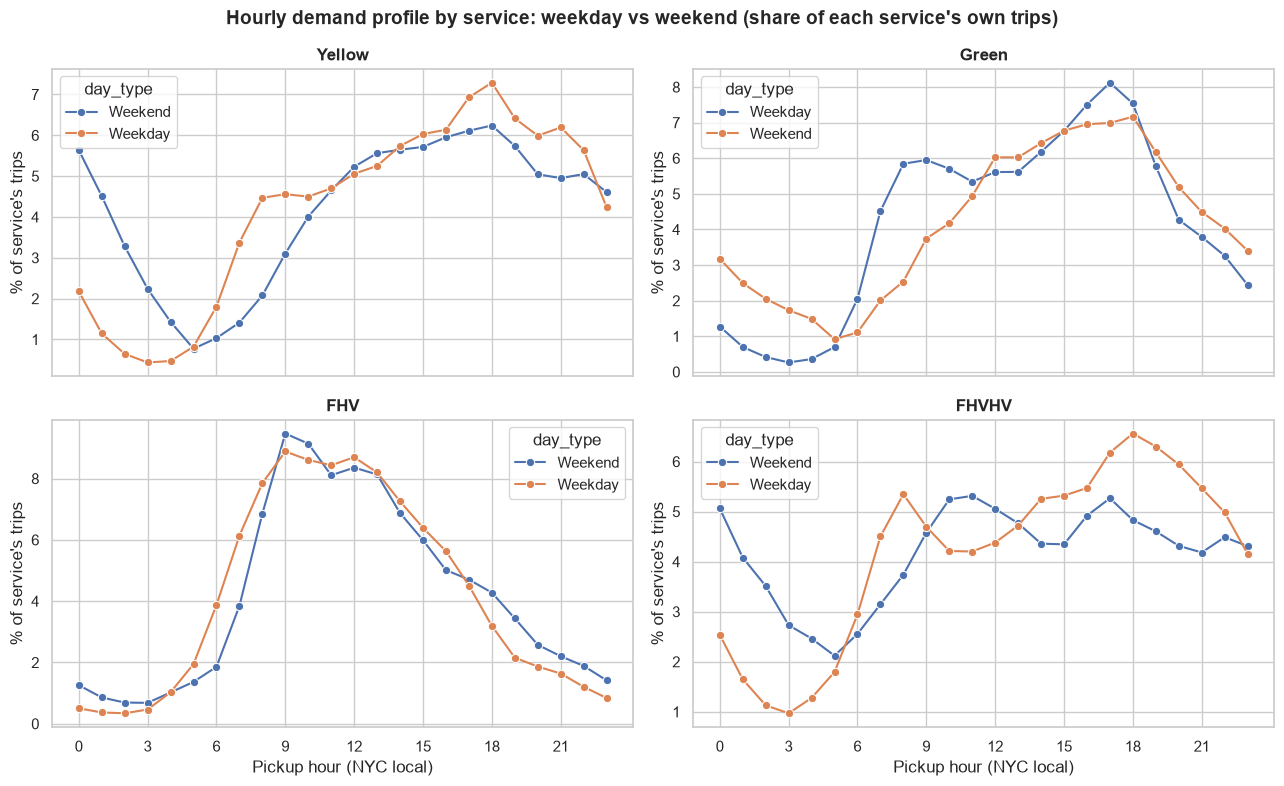

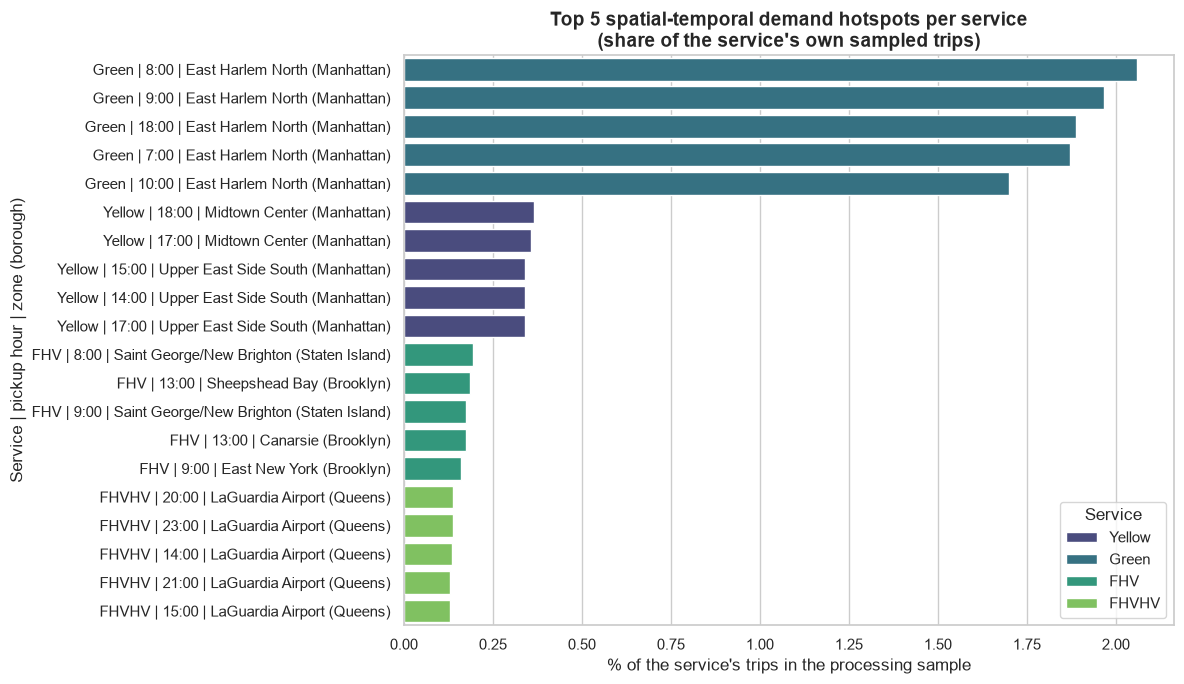

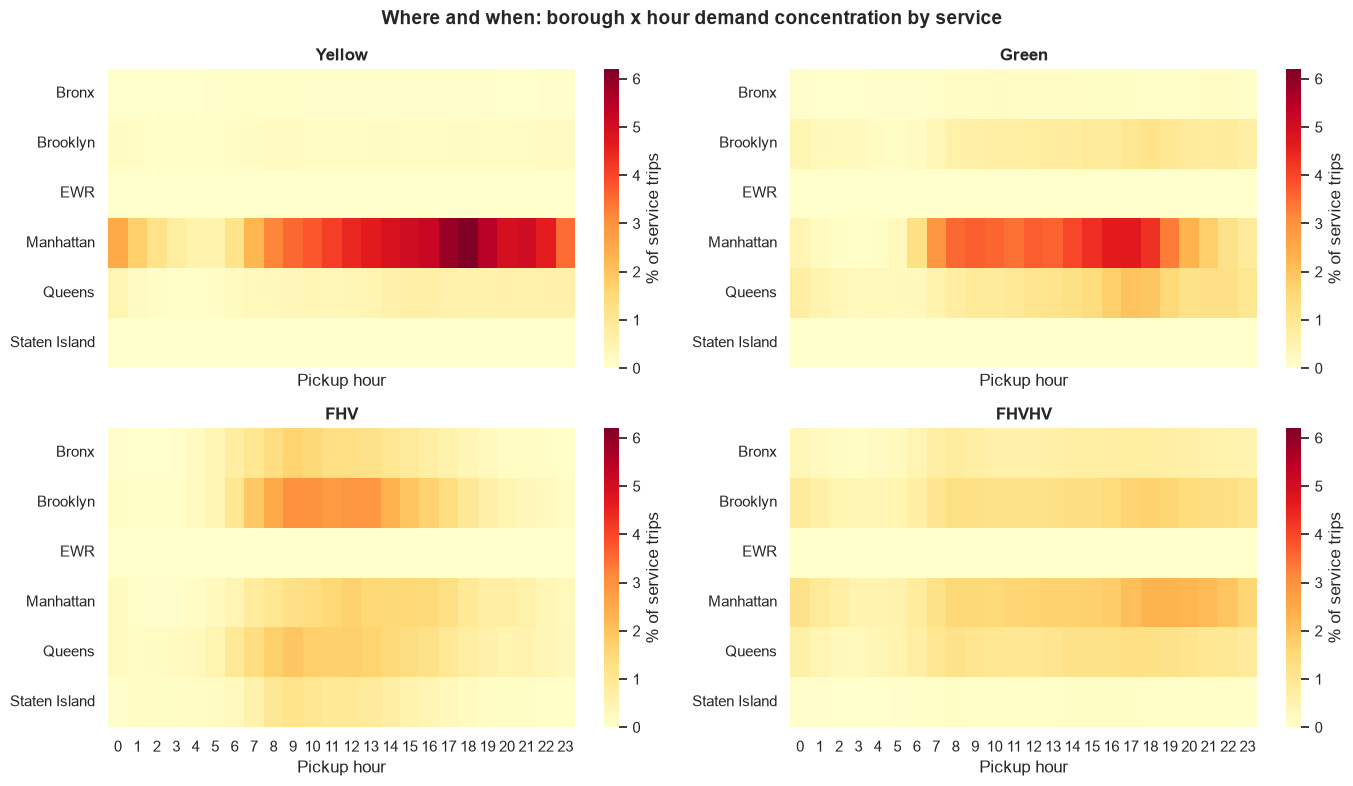

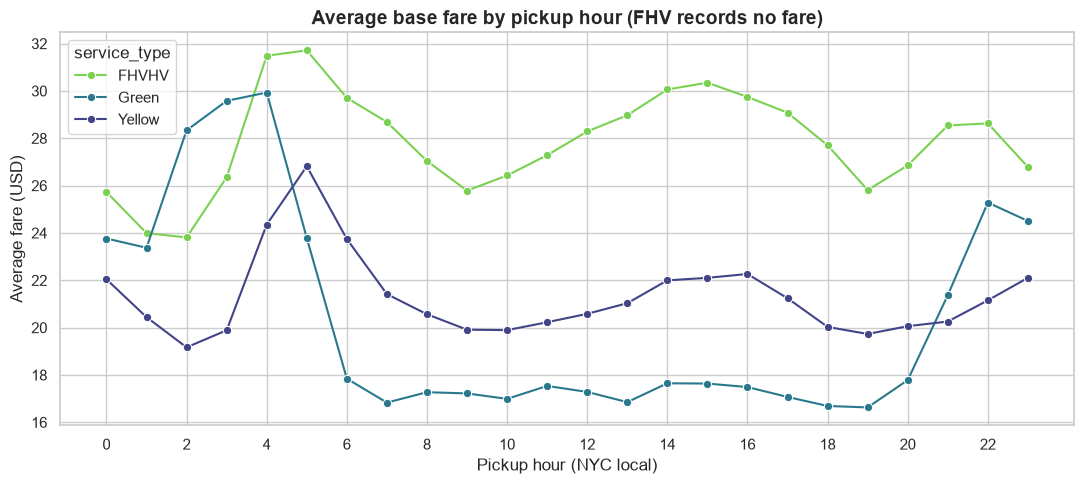

In [16]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)
sns.set_theme(style="whitegrid")
service_order = ["Yellow", "Green", "FHV", "FHVHV"]
palette = dict(zip(service_order, sns.color_palette("viridis", 4)))

# ---- Figure 1: hourly demand profile, weekday vs weekend ----
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, svc in zip(axes.ravel(), service_order):
    sub = hourly[hourly["service_type"] == svc]
    sns.lineplot(data=sub, x="pickup_hour", y="share_pct", hue="day_type", marker="o", ax=ax)
    ax.set_title(svc, fontweight="bold")
    ax.set_xlabel("Pickup hour (NYC local)")
    ax.set_ylabel("% of service's trips")
    ax.set_xticks(range(0, 24, 3))
fig.suptitle("Hourly demand profile by service: weekday vs weekend (share of each service's own trips)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig1_hourly_profile.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Figure 2: top hotspots (zone + hour) per service ----
plot_df = top_peaks.sort_values("share_pct", ascending=False)
plt.figure(figsize=(12, 7))
sns.barplot(data=plot_df, x="share_pct", y="hotspot_label", hue="service_type",
            hue_order=service_order, palette=palette, dodge=False)
plt.title("Top 5 spatial-temporal demand hotspots per service\n(share of the service's own sampled trips)",
          fontsize=14, fontweight="bold")
plt.xlabel("% of the service's trips in the processing sample")
plt.ylabel("Service | pickup hour | zone (borough)")
plt.legend(title="Service")
plt.tight_layout()
plt.savefig("figures/fig2_top_hotspots.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Figure 3: borough x hour heatmaps ----
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
vmax = borough_hour["share_pct"].max()
for ax, svc in zip(axes.ravel(), service_order):
    pivot = (borough_hour[borough_hour["service_type"] == svc]
             .pivot(index="Borough", columns="pickup_hour", values="share_pct").fillna(0))
    sns.heatmap(pivot, cmap="YlOrRd", vmin=0, vmax=vmax, ax=ax, cbar_kws={"label": "% of service trips"})
    ax.set_title(svc, fontweight="bold")
    ax.set_xlabel("Pickup hour")
    ax.set_ylabel("")
fig.suptitle("Where and when: borough x hour demand concentration by service", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig3_borough_hour_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Figure 4: average fare by hour (services that record a fare) ----
fare_df = hourly.groupby(["service_type", "pickup_hour"]).agg(fs=("fare_sum", "sum"), fn=("fare_n", "sum")).reset_index()
fare_df = fare_df[fare_df["fn"] > 0]
fare_df["avg_fare"] = fare_df["fs"] / fare_df["fn"]
plt.figure(figsize=(11, 5))
sns.lineplot(data=fare_df, x="pickup_hour", y="avg_fare", hue="service_type", palette=palette, marker="o")
plt.title("Average base fare by pickup hour (FHV records no fare)", fontsize=14, fontweight="bold")
plt.xlabel("Pickup hour (NYC local)")
plt.ylabel("Average fare (USD)")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig("figures/fig4_avg_fare_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
spark.stop()